# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print('# Cantidad de valores nulos')
print(users.isna().sum())# Proporción de valores nulos)

# Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [15]:
print('\n# Proporción de valores nulos')
print(users.isna().mean() * 100) # cantidad de nulos para usage


# Proporción de valores nulos
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


**Comentario** 
### Valores nulos

#### Dataset users
- La columna `city` presenta 469 valores nulos (11.73%).
- La columna `churn_date` presenta 3534 valores nulos (88.35%).

**Acciones recomendadas:**
- `city`: el porcentaje es moderado, por lo que se recomienda investigar la causa de los valores faltantes y evaluar imputación o mantenerlos como categoría "Desconocido".
- `churn_date`: el alto porcentaje de nulos es esperado, ya que la mayoría de los clientes probablemente continúan activos y no tienen fecha de cancelación. Se recomienda conservar los nulos e interpretarlos como clientes activos.

#### Dataset usage
- La columna `date` presenta 50 valores nulos (0.13%).
- La columna `duration` presenta 22076 valores nulos (55.19%).
- La columna `length` presenta 17896 valores nulos (44.74%).

**Acciones recomendadas:**
- `date`: el porcentaje es muy bajo; puede imputarse o eliminarse sin afectar significativamente el análisis.
- `duration` y `length`: los nulos parecen estar asociados al tipo de actividad registrada (llamadas o mensajes). Antes de imputar o eliminar, es necesario analizar la variable `type` para verificar si la ausencia de valores es lógica según el evento registrado.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
users[['user_id', 'age']].describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` parece ser un identificador único, no presenta valores negativos ni inconsistencias evidentes
- La columna `age` Es necesario verificar si existen edades muy bajas (0, o negativas) o excesivamente altas (>100 años), que podrían indicar errores de captura de datos.

In [17]:
usage[['id', 'user_id', 'duration', 'length']].describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



### Análisis de columnas numéricas de usage

- La columna `id` contiene 40.000 registros, con valores entre 1 y 40.000, por lo que parece funcionar correctamente como identificador único.
- La columna `user_id` presenta valores entre 10.000 y 13.999, sin evidencias de valores negativos o inconsistentes.
- La columna `duration` tiene una media de 5.20 minutos y valores entre 0 y 120 minutos. Se observan registros con duración igual a 0, que podrían corresponder a llamadas perdidas o registros incompletos y deben revisarse.
- La columna `length` tiene una media de 52.13 caracteres y valores entre 0 y 1490 caracteres. También existen registros con longitud igual a 0, lo que podría indicar mensajes vacíos o errores de captura.

### Posibles valores inválidos o sentinelas

- No se identifican valores negativos en las variables numéricas.
- Los valores iguales a 0 en `duration` y `length` requieren validación para determinar si representan eventos válidos o errores de registro.
- Existen valores máximos elevados (120 minutos en llamadas y 1490 caracteres en mensajes), pero no pueden considerarse inválidos sin un análisis adicional de outliers.

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'\n{col}')
    print(users[col].value_counts(dropna=False))



city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



### Análisis de columnas categóricas de users

#### Columna `city`
- Se identifican ciudades válidas como Bogotá, CDMX, Medellín, GDL, Cali y MTY.
- Existen 469 valores nulos (11.73%), lo que coincide con el análisis previo de valores faltantes.
- Se encontraron 96 registros con el valor `"?"`, el cual puede considerarse un valor sentinela o una categoría inválida utilizada para representar información desconocida.
- Bogotá es la ciudad con mayor número de usuarios registrados (808).

**Acción recomendada:**
- Reemplazar `"?"` por valores nulos (`NaN`) para tratar ambos casos de forma consistente.
- Evaluar posteriormente si los valores faltantes deben imputarse o mantenerse como "Desconocido".

#### Columna `plan`
- Solo se observan dos categorías: `Basico` (2595 registros) y `Premium` (1405 registros).
- No se identifican valores nulos ni categorías inesperadas.
- La distribución indica que aproximadamente el 65% de los usuarios tienen el plan Básico y el 35% el plan Premium.

**Acción recomendada:**
- No se requieren correcciones en esta variable.
- Puede utilizarse posteriormente para realizar segmentaciones y comparaciones de comportamiento entre planes..

In [20]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

### Análisis de la columna `type`

- La columna `type` presenta únicamente dos categorías: `text` (22.092 registros) y `call` (17.908 registros).
- No se identifican valores nulos ni categorías inesperadas.
- La distribución muestra una mayor cantidad de registros asociados al envío de mensajes de texto que a llamadas.
- Los valores observados son coherentes con la naturaleza del negocio y con las variables disponibles en el dataset.

**Acción recomendada:**
- No se identifican valores inválidos o sentinelas en esta columna, por lo que no se requieren ajustes.
- La variable puede utilizarse para segmentar el análisis de consumo entre llamadas y mensajes, así como para validar los valores nulos observados en las columnas `duration` y `length`.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

### Valores inválidos o sentinelas

Durante la exploración se identificó un posible valor sentinela en la columna `city`, representado por el carácter `"?"` en 96 registros. Este valor no corresponde a una ciudad válida y probablemente fue utilizado para representar información desconocida o no registrada.

En las demás variables exploradas no se encontraron valores categóricos inesperados. La columna `plan` contiene únicamente las categorías `Basico` y `Premium`, mientras que la columna `type` presenta únicamente los valores `call` y `text`.

Respecto a las variables numéricas, no se identificaron valores negativos; sin embargo, se observaron registros con valor 0 en las columnas `duration` y `length`, los cuales deberán validarse para determinar si corresponden a eventos válidos o posibles inconsistencias de captura.

**Acciones recomendadas:**
- Reemplazar el valor `"?"` de la columna `city` por valores nulos (`NaN`).
- Revisar la consistencia de los registros con duración o longitud igual a 0.
- Mantener sin modificaciones las columnas `plan` y `type`, ya que no presentan inconsistencias evidentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [23]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [24]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
### Columna `date`

- Todos los registros válidos corresponden al año 2024, con un total de 39.950 observaciones.
- No se identifican años fuera del rango esperado ni fechas futuras.
- La información temporal es consistente con el alcance del proyecto, el cual establece que los datos disponibles corresponden hasta el año 2024.
- Los registros faltantes identificados previamente representan una proporción muy baja del dataset (0.13%), por lo que no afectan significativamente el análisis temporal.

**Acción recomendada:**
- Mantener la columna en formato fecha (`datetime`).
- Utilizar esta variable como referencia temporal para los análisis de uso de llamadas y mensajes.
- Evaluar los registros con fecha nula para determinar si deben eliminarse o mantenerse según el contexto del análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

### Fechas fuera de rango

Se identificó una inconsistencia en la columna `reg_date`, donde 40 usuarios presentan fechas de registro correspondientes al año 2026. Debido a que el proyecto establece que la información está disponible únicamente hasta 2024, estos registros deben revisarse por posible error de captura.

Por otra parte, la columna `date`, que será la base para el análisis del comportamiento de uso, presenta registros únicamente del año 2024 y no muestra anomalías temporales. Esto indica que la información de actividad de los usuarios es consistente y puede utilizarse con confianza en las etapas posteriores del análisis.

**Acciones recomendadas:**
- Investigar los registros de `reg_date` correspondientes al año 2026.
- Mantener `date` como variable temporal principal para el análisis.
- Conservar el formato datetime en ambas columnas para facilitar análisis por periodos, meses y tendencias de uso.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [27]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [29]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['duration'].agg(
    total='size',
    nulos=lambda x: x.isna().sum(),
    porcentaje_nulos=lambda x: round(x.isna().mean()*100,2)
)

,total,nulos,porcentaje_nulos
type,,,
call,17908,0.0,0.00
text,22092,22076.0,99.93


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico**

Se consolidó la información de uso a nivel de usuario mediante la agregación de los registros de llamadas y mensajes contenidos en el dataset usage. Para cada cliente se calcularon tres métricas clave: la cantidad total de mensajes enviados (cant_mensajes), la cantidad total de llamadas realizadas (cant_llamadas) y la duración acumulada de las llamadas (cant_minutos_llamada).

Posteriormente, esta información fue integrada con la base de usuarios (users), permitiendo construir un perfil de comportamiento individual para cada cliente. Esta tabla consolidada facilita la comparación entre segmentos demográficos, la identificación de patrones de consumo y la detección de usuarios con comportamientos atípicos.

La agregación a nivel de usuario reduce la complejidad de los datos transaccionales y genera una base adecuada para realizar análisis descriptivos, segmentaciones y evaluaciones de uso según variables como edad, ciudad y plan contratado.

Acción recomendada

Se recomienda utilizar esta tabla consolidada como base principal para el análisis exploratorio posterior, ya que permite evaluar diferencias de comportamiento entre clientes, identificar posibles outliers y generar insights comerciales relacionados con el uso de los servicios de telecomunicaciones.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [40]:
# Resumen estadístico de las columnas numéricas

user_profile[['age',
              'cant_mensajes',
              'cant_llamadas',
              'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [41]:
# Distribución porcentual del tipo de plan
plan_dist = (
    user_profile['plan']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(plan_dist)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

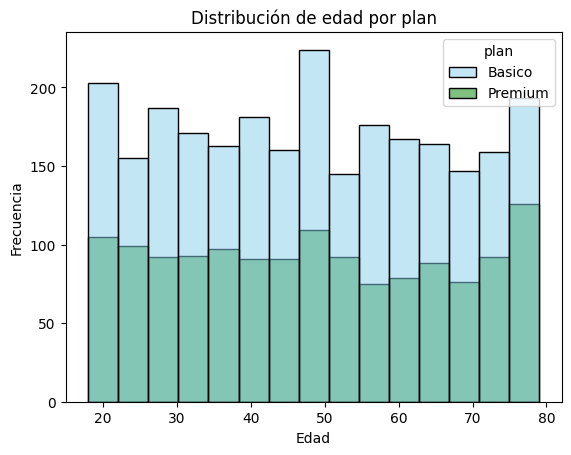

In [42]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edades presenta un comportamiento relativamente uniforme entre los 18 y 80 años para ambos planes. Se observa que el plan Básico concentra una mayor cantidad de usuarios en todos los rangos de edad, lo cual es consistente con la mayor participación de este plan dentro de la base de clientes.

No se evidencian diferencias marcadas en la composición etaria entre los usuarios de los planes Básico y Premium, ya que ambos presentan una distribución similar a lo largo de los distintos grupos de edad. Esto sugiere que la edad, por sí sola, no parece ser un factor determinante en la elección del plan contratado.

Adicionalmente, la distribución no presenta una asimetría pronunciada ni concentraciones extremas en rangos específicos de edad, por lo que puede considerarse relativamente equilibrada. En consecuencia, será necesario analizar otras variables de comportamiento, como la cantidad de mensajes, llamadas y minutos consumidos, para identificar diferencias más relevantes entre los usuarios de cada plan.

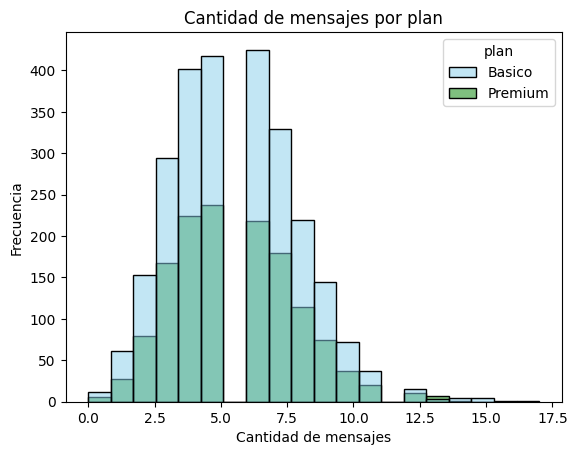

In [43]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ....

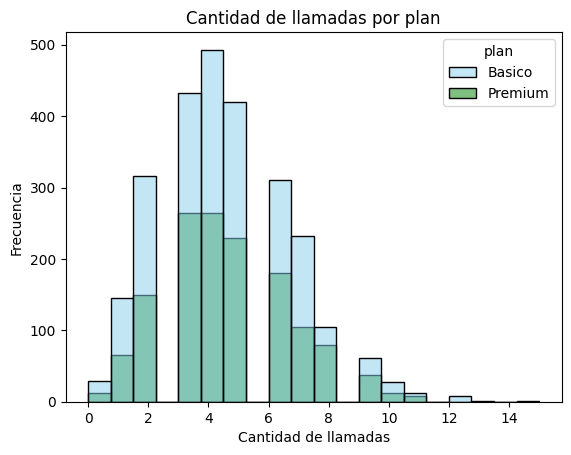

In [44]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La distribución de la cantidad de mensajes presenta una forma aproximadamente normal, con una concentración importante de usuarios entre 4 y 7 mensajes durante el período analizado. Tanto el plan Básico como el Premium muestran patrones de comportamiento similares, aunque el plan Básico registra una mayor frecuencia de usuarios debido a su mayor participación dentro de la base de clientes.

Se observa una ligera asimetría positiva (sesgo hacia la derecha), evidenciada por la presencia de algunos usuarios que envían más de 10 mensajes, aunque estos casos representan una proporción reducida del total. No se identifican valores extremadamente alejados del resto de la distribución.

La superposición de ambos histogramas sugiere que el tipo de plan no genera diferencias significativas en la cantidad de mensajes enviados por los usuarios. Por lo tanto, el comportamiento de mensajería parece ser relativamente homogéneo entre clientes de los planes Básico y Premium.

 **En Conclusión**: La mayoría de los usuarios, independientemente del plan contratado, presentan niveles de uso de mensajería similares, concentrados en rangos medios de consumo. Será necesario analizar las variables de llamadas y minutos consumidos para determinar si existen diferencias más marcadas en otros patrones de uso del servicio.

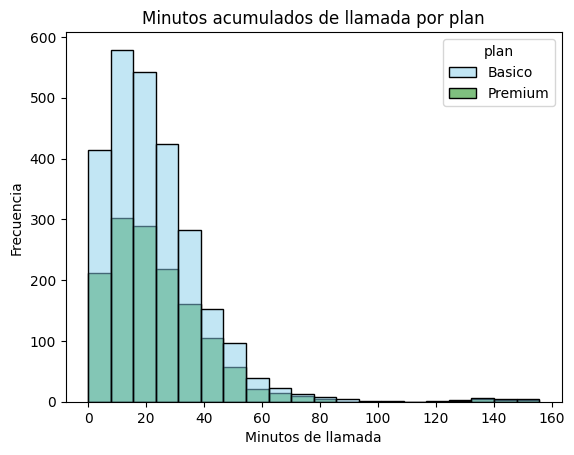

In [45]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Minutos acumulados de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
La distribución de los minutos acumulados de llamada presenta una asimetría positiva marcada (sesgo hacia la derecha). La mayor parte de los usuarios de ambos planes concentra su consumo entre 5 y 30 minutos, mientras que un grupo reducido registra consumos considerablemente más altos.
Se observa que tanto los usuarios del plan Básico como del Premium exhiben patrones de comportamiento similares en cuanto a la duración de las llamadas. Sin embargo, existen algunos casos aislados con consumos superiores a los 100 minutos, los cuales podrían considerarse valores atípicos y requerir una revisión más detallada en la etapa de detección de outliers.
La concentración de usuarios en rangos bajos y medios de consumo indica que el servicio de voz es utilizado de manera moderada por la mayoría de los clientes. Adicionalmente, la superposición de ambas distribuciones sugiere que el tipo de plan no genera diferencias sustanciales en el tiempo total de llamadas acumuladas.
**Conclusión:** El consumo de minutos de llamada presenta una distribución sesgada hacia valores bajos, con una pequeña proporción de usuarios de alto consumo que podrían representar perfiles de uso intensivo. Estos casos serán relevantes para la identificación de segmentos específicos y la evaluación de posibles oportunidades de optimización comercial.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

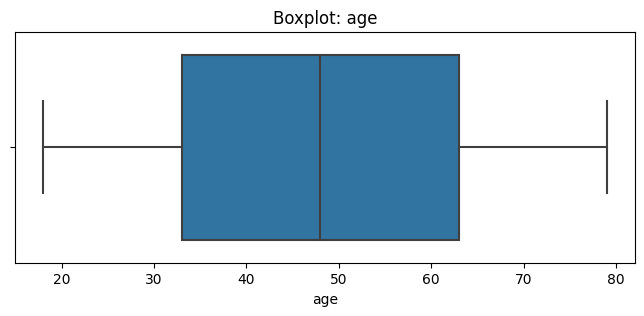

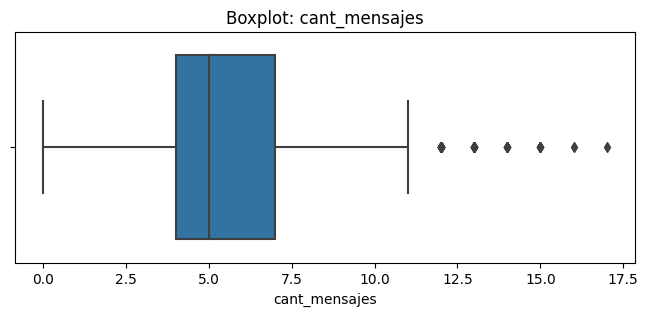

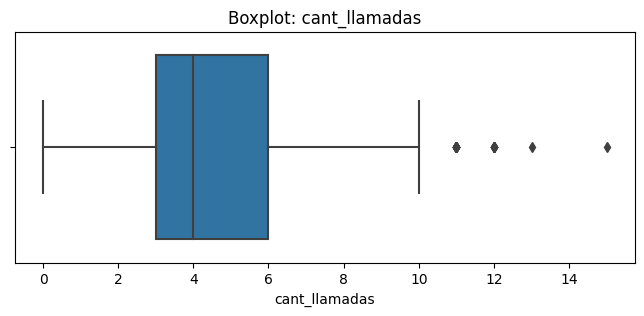

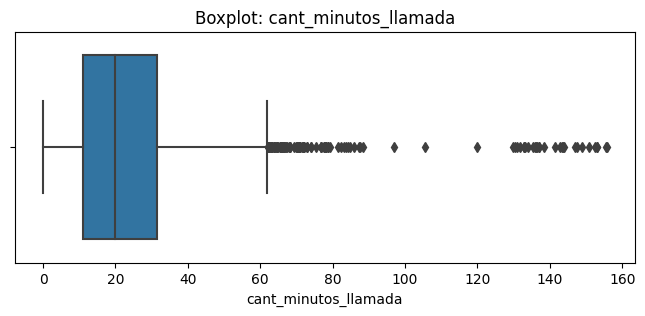

In [46]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- age: No se observan valores atípicos. La distribución de edades se encuentra dentro de un rango esperado (aproximadamente entre 18 y 80 años), por lo que no se identifican registros que sugieran errores de captura o casos anómalos.
- cant_mensajes: Se identifican algunos valores atípicos superiores, correspondientes a usuarios que envían una cantidad de mensajes significativamente mayor que la mayoría. Estos registros pueden representar clientes con un uso intensivo del servicio de mensajería y no necesariamente errores en los datos.
- cant_llamadas: Se observan varios valores extremos por encima del límite superior de la distribución. Estos casos corresponden a usuarios con una frecuencia de llamadas superior al comportamiento típico, lo que podría indicar perfiles de alto consumo o necesidades específicas de comunicación.
- cant_minutos_llamada: Es la variable con mayor presencia de valores atípicos. Se evidencia una fuerte asimetría positiva, con algunos usuarios acumulando una cantidad considerablemente mayor de minutos de llamada. Estos registros son relevantes para el análisis, ya que pueden representar clientes de alto valor o segmentos con patrones de uso diferenciados.

In [47]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print(f'Máximo observado: {user_profile[col].max()}')




cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Máximo observado: 17.0

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Máximo observado: 15.0

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Máximo observado: 155.69


In [48]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
-cant_mensajes: El método IQR establece un límite superior de 11.5 mensajes, mientras que el valor máximo observado es 17 mensajes. Aunque existen registros que superan este umbral, la diferencia no es excesivamente alta y puede explicarse por usuarios con una mayor frecuencia de mensajería. Dado que estos valores representan comportamientos plausibles dentro del servicio, se recomienda mantener los outliers para conservar la variabilidad real de los clientes.
- cant_llamadas: El límite superior calculado es de 10.5 llamadas, mientras que el máximo registrado es 15 llamadas. Se identifican algunos usuarios con una frecuencia de llamadas superior al patrón general, pero estos casos siguen siendo razonables dentro del contexto de una empresa de telecomunicaciones. Por lo tanto, no se recomienda eliminar estos registros, ya que podrían corresponder a segmentos de usuarios con un uso más intensivo del servicio.
- cant_minutos_llamada: Esta variable presenta la mayor diferencia entre el límite superior (61.86 minutos) y el valor máximo observado (155.69 minutos), evidenciando la presencia de varios valores extremos. Sin embargo, estos registros pueden representar usuarios con un consumo elevado de llamadas y constituyen información valiosa para la segmentación y el análisis de patrones de uso. En consecuencia, se recomienda mantener los outliers, ya que reflejan comportamientos reales y no existen indicios de errores de captura.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [49]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    
    if edad < 30:
        return 'Joven'
    
    elif edad < 60:
        return 'Adulto'
    
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

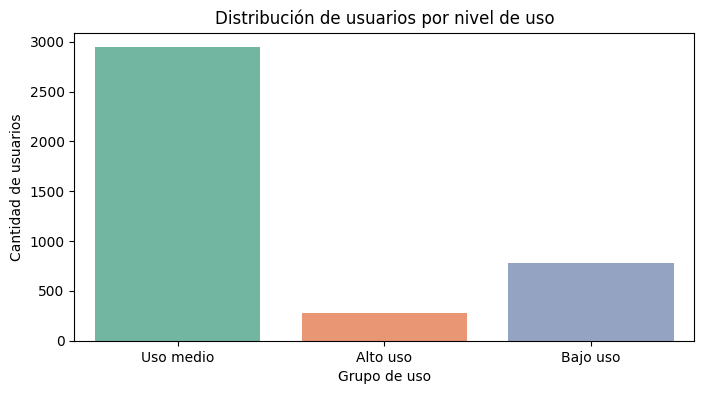

In [53]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,4))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='Set2'
)

plt.title('Distribución de usuarios por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

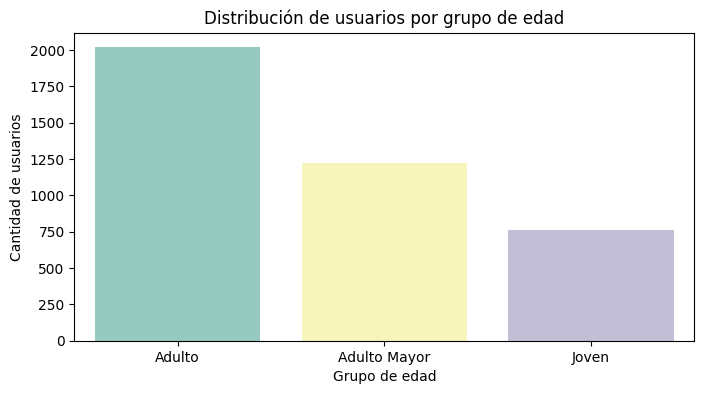

In [54]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,4))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='Set3'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Durante la etapa de calidad de datos se identificaron varios problemas:

La columna city presentó 469 valores nulos (11.73%) en la tabla de usuarios.
La columna churn_date presentó 3.534 valores nulos (88.35%). Estos nulos son consistentes con clientes que permanecen activos y no representan un error.
En la tabla de uso, la variable duration presentó 22.076 valores nulos (55.19%) y la variable length 17.896 valores nulos (44.74%).
Se identificaron 40 registros con fechas de registro en 2026, año que se encuentra fuera del periodo de análisis (hasta 2024), por lo que fueron tratados como valores faltantes.
También se detectó el valor centinela "?" en la variable city, el cual fue reemplazado por valores nulos para mantener la consistencia de la información.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
 Se identificaron dos tipos de segmentación:

Segmentación por edad
Adultos (30-59 años): constituyen el grupo más numeroso de clientes.
Adultos Mayores (60 años o más): representan una proporción importante de la base de usuarios.
Jóvenes (menores de 30 años): conforman el grupo menos representativo.
Segmentación por nivel de uso
Uso medio: representa aproximadamente el 74% de los usuarios y corresponde al comportamiento predominante.
Bajo uso: alrededor del 20% de los usuarios presentan consumos reducidos de llamadas y mensajes.
Alto uso: cerca del 7% de los clientes muestran patrones intensivos de consumo.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los usuarios clasificados como Alto uso representan el segmento más valioso para la compañía, ya que generan un mayor consumo de servicios de llamadas y mensajería.

Adicionalmente, los adultos con niveles elevados de consumo constituyen una oportunidad importante para la comercialización de planes premium y estrategias de fidelización, debido a su alta participación dentro de la base de clientes.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
  Se identificaron valores atípicos en las variables:

cant_mensajes
cant_llamadas
cant_minutos_llamada

El análisis mediante diagramas de caja y el método IQR mostró que existen usuarios que registran consumos considerablemente superiores al promedio.

Sin embargo, estos valores no parecen corresponder a errores de captura, sino a clientes con comportamientos reales de alto consumo. Por esta razón, los registros fueron conservados en el análisis.

Para el negocio, estos usuarios representan una oportunidad estratégica, ya que pueden corresponder a clientes de alto valor que demandan planes con mayores beneficios o servicios especializados.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- 
  Diseñar planes diferenciados para usuarios de alto uso, incluyendo mayores beneficios en llamadas y mensajería.
Implementar campañas de fidelización dirigidas a clientes con consumos elevados para reducir el riesgo de abandono.
Desarrollar promociones orientadas a usuarios de bajo uso con el fin de incrementar su utilización de los servicios.
Crear ofertas específicas para adultos mayores, considerando sus necesidades de comunicación y facilidad de uso.
Realizar análisis complementarios por tipo de plan (Básico y Premium) para identificar oportunidades de optimización de la oferta comercial.
Utilizar la segmentación identificada para personalizar campañas de marketing y mejorar la experiencia del cliente.

✍️ **Escribe aquí tu análisis ejecutivo:**
El análisis permitió identificar que la mayoría de los clientes de ConectaTel corresponden a usuarios adultos con niveles de consumo medio. Asimismo, se detectó un grupo reducido de usuarios de alto consumo que representa una oportunidad importante para incrementar ingresos mediante productos y servicios especializados. Los valores atípicos encontrados reflejan comportamientos reales de uso y aportan información valiosa para la segmentación y toma de decisiones comerciales. En consecuencia, la empresa debería enfocar sus esfuerzos en fortalecer la retención de clientes de alto valor, incentivar el consumo de usuarios de bajo uso y desarrollar ofertas diferenciadas según la edad y el comportamiento de consumo.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La variable city presentó 469 valores nulos (11,73%) y 96 registros con el valor sentinela "?", los cuales fueron reemplazados por valores nulos para evitar interpretaciones incorrectas.
- La variable churn_date presentó 3.534 valores nulos (88,35%). Este comportamiento es coherente con clientes que continúan activos, por lo que los valores fueron conservados.
- En la tabla usage, las variables duration y length presentaron porcentajes elevados de valores nulos (55,19% y 44,74% respectivamente). El análisis mostró que estos nulos dependen del tipo de actividad registrada (llamadas o mensajes), por lo que corresponden a valores estructurales y no a errores de captura.
- Se detectaron 40 fechas de registro correspondientes al año 2026, fuera del rango esperado (datos hasta 2024). Estas fechas fueron consideradas inconsistentes y marcadas como valores nulos.


🔍 **Segmentos por Edad**
- El segmento Adulto concentra aproximadamente la mitad de los usuarios de ConnectaTel.
- Los Adultos Mayores representan una proporción relevante del mercado, lo que evidencia oportunidades para productos adaptados a este grupo.
- Los usuarios jóvenes constituyen el grupo más pequeño dentro de la cartera de clientes.

📊 **Segmentos por Nivel de Uso**
- El segmento de Uso Medio concentra la gran mayoría de los clientes (aproximadamente el 70% de la muestra).
- El segmento de Bajo Uso representa una proporción moderada de usuarios.
- El segmento de Alto Uso es el más pequeño, pero corresponde a los clientes con mayor interacción con los servicios.



➡️ Esto sugiere que la mayoría de los clientes utilizan los servicios de forma moderada, lo que indica que los planes actuales parecen ajustarse adecuadamente a las necesidades promedio de la base de usuarios.


💡 **Recomendaciones**

1. Fortalecer la oferta Premium

Los usuarios de alto consumo muestran una clara disposición a utilizar más servicios. Se recomienda:

- Incrementar beneficios para usuarios Premium.
- Ofrecer paquetes con mayor cantidad de minutos y mensajería.
- Diseñar programas de fidelización específicos para este segmento.
2. Crear campañas para usuarios de bajo uso

Los usuarios con baja interacción representan una oportunidad de crecimiento.

Se recomienda:

 - Promociones de activación.
- Bonos de llamadas y mensajes.
- Estrategias de engagement para aumentar el uso del servicio.
  
3. Diseñar productos para adultos mayores

Dado el peso de este segmento en la base de clientes:
- Simplificar planes y beneficios.
- Ofrecer atención preferencial.
- Implementar campañas enfocadas en comunicación familiar y seguridad.
- 
4. Optimizar la captación de usuarios jóvenes

La baja participación de este grupo sugiere una oportunidad comercial.

Se recomienda:
- Planes con beneficios digitales.
- Mayor integración con servicios de datos y entretenimiento.
Estrategias de marketing dirigidas a públicos jóvenes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`